<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/gru_optimizations/2lstm_1hidden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# ================== IMPORTS ==================
import os
import random
import itertools
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Bidirectional

from sklearn.linear_model import Ridge  # optional (for ensemble)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.losses import Huber

# ================== CONFIG / CONSTANTS ==================
# Suppress TF logs for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Path to Excel file
INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

# Train/test split settings
TEST_SET_DAYS = 60      # last 60 days reserved for test
VAL_DAYS = 90           # validation fold length
N_SPLITS = 4            # number of CV folds
N_TIMESTEPS = 7         # GRU sequence window

# Target columns (meal periods)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Feature engineering settings
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# GRU training settings
GRU_EPOCHS = 50
GRU_BATCH_SIZE = 32

# Search spaces (GRU)
SEARCH_SPACE_GRU_LR = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
SEARCH_SPACE_GRU_UNITS = [32, 64, 128, 256]

# Optional Ridge search space (if using ensemble)
SEARCH_SPACE_RIDGE_ALPHA = [0.1, 1.0, 10.0, 100.0]


In [52]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """
    Add lag and rolling features for each target column.
    Shift ensures only past values are used (no leakage).
    """
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    """
    Convert tabular data into sequences for GRU.
    Each sample uses n_timesteps of history to predict the next target.
    """
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

def smape(y_true, y_pred, eps=1e-6):
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0

def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def build_bigru_model(input_shape_gru, lr, units):
    """
    Build a stacked Bidirectional GRU model.
    """
    gru_input = Input(shape=input_shape_gru, name='gru_input')

    # First GRU layer returns sequences
    x = Bidirectional(GRU(units, return_sequences=True))(gru_input)
    x = Dropout(0.3)(x)

    # Final GRU layer returns last state
    x = Bidirectional(GRU(units // 2, return_sequences=False))(x)
    x = Dropout(0.3)(x)

    x = Dense(units // 4, activation='relu')(x)
    output = Dense(1, activation='linear', name='output')(x)

    model = Model(inputs=gru_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='Huber', metrics=['mae'])
    return model

def dynamic_weights(y_true, y_pred_a, y_pred_b):
    """
    Compute ensemble weights based on RMSE of each model.
    Lower RMSE → higher weight.
    """
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b

# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    """Plot actual vs predicted revenue for test set."""
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """Plot residuals (Actual - Predicted) over time for test set."""
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_training_curves(history, center_name, meal_period):
    """
    Show training/validation Loss and MAE curves inline in notebook output.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss (MSE)', color='#1f77b4', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='#ff7f0e', lw=2)

    plt.title(f'Training Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Metric Value')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [53]:
# ================== CV SCORING ==================
def score_ensemble_gru_and_weights(params, X_train_full, Y_train_full, tscv,
                                   raw_target_col, numeric_features, categorical_features):
    """
    CV scoring for (lr, units, alpha) on hybrid ensemble.
    Returns avg_rmse across folds, avg_w_gru, avg_w_ridge.
    Ensemble weights are computed per fold on validation only.
    """
    lr, units, alpha = params
    fold_rmses, fold_w_gru, fold_w_ridge = [], [], []

    for train_idx, val_idx in tscv.split(X_train_full):
        # Split train/val
        X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
        Y_val = Y_train_full.iloc[val_idx][raw_target_col]

        # Scale numeric features (fit on train only)
        scaler = RobustScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
        X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

        # Combine numeric + categorical
        X_train_cv_scaled = pd.concat(
            [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
             X_train_cv_raw[categorical_features]], axis=1)
        X_val_scaled = pd.concat(
            [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
             X_val_raw[categorical_features]], axis=1)

        # Sequence creation
        X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
        X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)
        if len(X_seq_train) == 0 or len(X_seq_val) == 0:
            continue

        # Ridge data aligned with sequences
        X_ridge_train = X_train_cv_scaled.iloc[N_TIMESTEPS:]
        X_ridge_val = X_val_scaled.iloc[N_TIMESTEPS:]
        Y_ridge_train = Y_train_cv.iloc[N_TIMESTEPS:]

        # Train GRU
        tf.keras.backend.clear_session()
        gru_model = build_bigru_model((N_TIMESTEPS, X_seq_train.shape[2]), lr, units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
        gru_model.fit(X_seq_train, Y_seq_train,
                      validation_data=(X_seq_val, Y_seq_val),
                      epochs=GRU_EPOCHS, batch_size=GRU_BATCH_SIZE,
                      callbacks=[es_callback], verbose=0)
        y_pred_gru = gru_model.predict(X_seq_val, verbose=0).flatten()

        # Train Ridge
        ridge_model = Ridge(alpha=alpha).fit(X_ridge_train, Y_ridge_train)
        y_pred_ridge = ridge_model.predict(X_ridge_val).flatten()

        # Align lengths
        min_len = min(len(Y_seq_val), len(y_pred_gru), len(y_pred_ridge))
        if min_len == 0:
            continue

        Y_seq_val_trunc = Y_seq_val[:min_len]
        y_pred_gru_trunc = y_pred_gru[:min_len]
        y_pred_ridge_trunc = y_pred_ridge[:min_len]

        # Compute ensemble weights on validation only (no leakage)
        w_gru, w_ridge = dynamic_weights(Y_seq_val_trunc, y_pred_gru_trunc, y_pred_ridge_trunc)
        y_pred_val_ens = (w_gru * y_pred_gru_trunc) + (w_ridge * y_pred_ridge_trunc)

        # Fold RMSE
        rmse = np.sqrt(mean_squared_error(Y_seq_val_trunc, y_pred_val_ens))
        fold_rmses.append(rmse)
        fold_w_gru.append(w_gru)
        fold_w_ridge.append(w_ridge)

    # Return averages across folds
    return (np.mean(fold_rmses) if fold_rmses else float('inf'),
            float(np.mean(fold_w_gru)) if fold_w_gru else 0.5,
            float(np.mean(fold_w_ridge)) if fold_w_ridge else 0.5)

In [54]:
# ================== RANDOM SEARCH ==================
def random_search_tune(X_train_full, Y_train_full, tscv, raw_target_col,
                       numeric_features, categorical_features,
                       lr_list, units_list, alpha_list, n_trials=12):
    """
    Randomly sample n_trials combinations from discrete lists.
    Returns best (avg_cv_rmse, avg_w_gru, avg_w_ridge, best_params).
    """
    grid = list(itertools.product(lr_list, units_list, alpha_list))
    combos = random.sample(grid, min(n_trials, len(grid)))

    best_rmse = float('inf')
    best_params = None
    best_w = (0.6, 0.4)

    for params in combos:
        avg_rmse, w_gru, w_ridge = score_ensemble_gru_and_weights(
            params=params,
            X_train_full=X_train_full,
            Y_train_full=Y_train_full,
            tscv=tscv,
            raw_target_col=raw_target_col,
            numeric_features=numeric_features,
            categorical_features=categorical_features
        )
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = params
            best_w = (w_gru, w_ridge)

    return best_rmse, best_w[0], best_w[1], best_params


def get_small_ranges_for_period(meal_period):
    """
    Optional: tighten ranges based on observed winners.
    Falls back to global GRU search spaces if not matched.
    """
    if meal_period == 'BreakFast':
        return [1e-3, 5e-3, 1e-2], [64], [10.0]
    if meal_period == 'Dinner':
        return [1e-4, 5e-4, 1e-3], [128, 64], [1.0, 10.0]
    if meal_period == 'Lunch':
        return [5e-4, 1e-3, 2e-3], [64, 128], [10.0, 100.0]
    return SEARCH_SPACE_GRU_LR, SEARCH_SPACE_GRU_UNITS, SEARCH_SPACE_RIDGE_ALPHA

In [55]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name):
    """
    Train hybrid GRU + Ridge model for one revenue center.
    Shows training curves and test plots inline in the notebook output cell.
    """
    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/test split by date
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # TimeSeriesSplit for CV tuning
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS, gap=N_TIMESTEPS)

    # Separate features
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')
        lr_list, units_list, alpha_list = get_small_ranges_for_period(meal_period)

        # 1. Hyperparameter Tuning (CV)
        best_cv_rmse, w_gru_cv, w_ridge_cv, best_params = random_search_tune(
            X_train_full=X_train_full, Y_train_full=Y_train_full, tscv=tscv,
            raw_target_col=raw_target_col, numeric_features=numeric_features,
            categorical_features=categorical_features, lr_list=lr_list,
            units_list=units_list, alpha_list=alpha_list, n_trials=12
        )
        best_lr, best_units, best_alpha = best_params
        print(f"✅ Optimal Params for {center_name} - {meal_period}: "
              f"LR={best_lr}, Units={best_units}, Alpha={best_alpha} | "
              f"CV RMSE={best_cv_rmse:.2f}, Weights(GRU={w_gru_cv:.2f}, Ridge={w_ridge_cv:.2f})")

        # 2. Prepare Data for Final Training
        final_scaler = RobustScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features, index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)
        Y_train_target = Y_train_full[raw_target_col].values

        # Create Sequences and split for training curves
        X_seq_total, Y_seq_total = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_tb, X_val_tb = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_tb, y_val_tb = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        # 3. TensorBoard Logging
        run_id = f"{center_name}_{meal_period}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
        log_dir = os.path.join("logs", "fit", run_id)
        tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

        # 4. Final GRU Model Training
        tf.keras.backend.clear_session()
        final_gru_model = build_bigru_model((N_TIMESTEPS, X_train_tb.shape[2]), best_lr, best_units)

        print(f"📊 Training Final Model for {center_name} - {meal_period} "
              f"(LR={best_lr}, Units={best_units}, Alpha={best_alpha})")

        history = final_gru_model.fit(
            X_train_tb, y_train_tb,
            validation_data=(X_val_tb, y_val_tb),
            epochs=GRU_EPOCHS,
            batch_size=GRU_BATCH_SIZE,
            callbacks=[tb_callback, es_callback],
            verbose=0
        )
        # Show curves inline
        plot_training_curves(history, center_name, meal_period)

        # Ridge Training (on full set aligned with sequences)
        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]
        final_ridge_model = Ridge(alpha=best_alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # 5. Test Evaluation
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features, index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)

        # Build GRU test sequences by appending last N_TIMESTEPS from train features
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_gru = final_gru_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        min_len_test = min(len(df_test_full), len(y_test_gru), len(y_test_ridge))
        y_test_ens = (w_gru_cv * y_test_gru[:min_len_test]) + (w_ridge_cv * y_test_ridge[:min_len_test])
        Y_test_actual = df_test_full[raw_target_col].values[:min_len_test]

        # Results Plotting inline
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_actual,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

        # Print summary row inline
        print({
            'Center': center_name,
            'Meal_Period': meal_period,
            'Best_LR': best_lr,
            'Best_Units': best_units,
            'Best_Alpha': best_alpha,
            'CV_RMSE': round(best_cv_rmse, 4),
            'CV_W_GRU': round(w_gru_cv, 4),
            'CV_W_Ridge': round(w_ridge_cv, 4)
        })


================= Revenue Centre 1 =================
✅ Optimal Params for Revenue Centre 1 - BreakFast: LR=0.005, Units=64, Alpha=10.0 | CV RMSE=678.68, Weights(GRU=0.50, Ridge=0.50)
📊 Training Final Model for Revenue Centre 1 - BreakFast (LR=0.005, Units=64, Alpha=10.0)


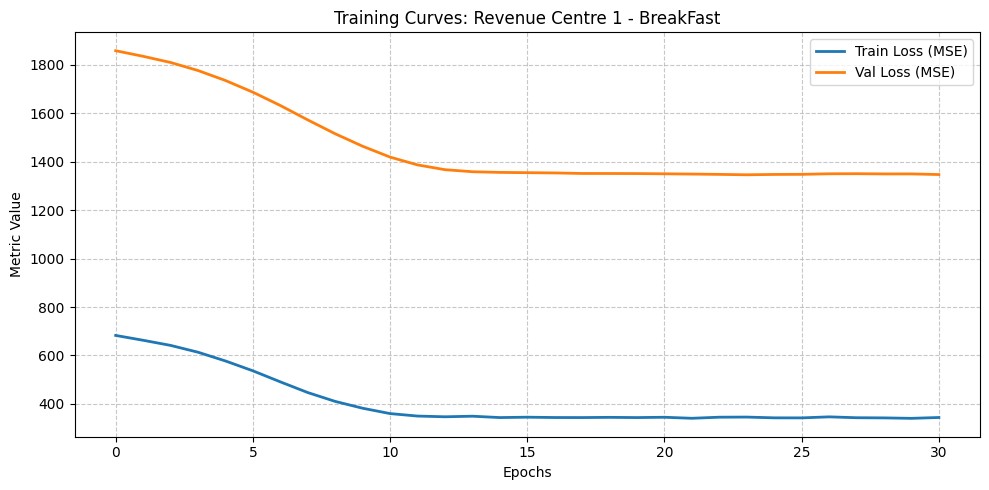

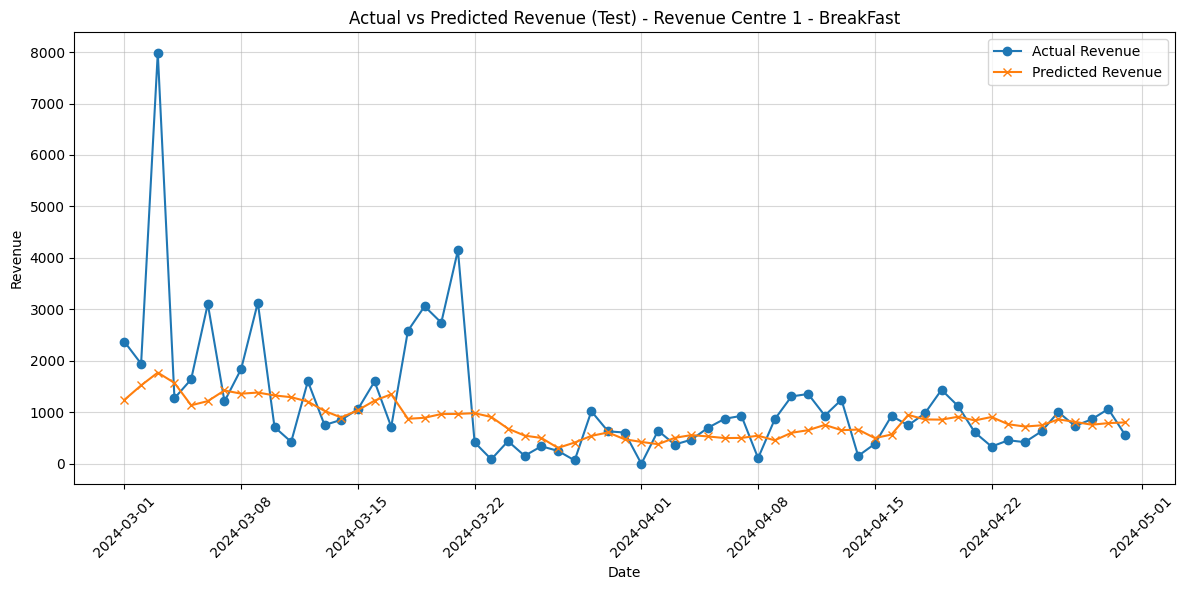

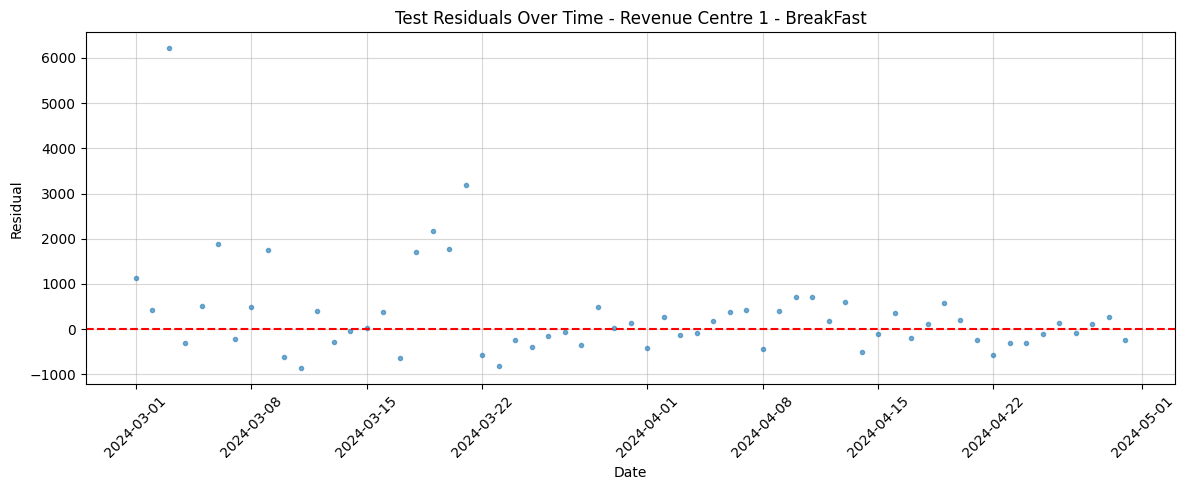

{'Center': 'Revenue Centre 1', 'Meal_Period': 'BreakFast', 'Best_LR': 0.005, 'Best_Units': 64, 'Best_Alpha': 10.0, 'CV_RMSE': np.float64(678.6826), 'CV_W_GRU': 0.5019, 'CV_W_Ridge': 0.4981}
✅ Optimal Params for Revenue Centre 1 - Dinner: LR=0.001, Units=128, Alpha=10.0 | CV RMSE=1315.74, Weights(GRU=0.35, Ridge=0.65)
📊 Training Final Model for Revenue Centre 1 - Dinner (LR=0.001, Units=128, Alpha=10.0)


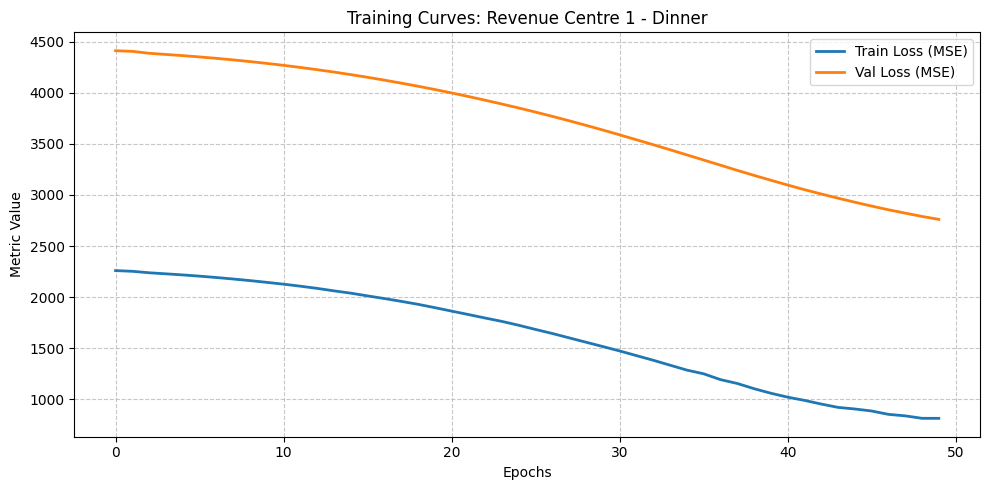

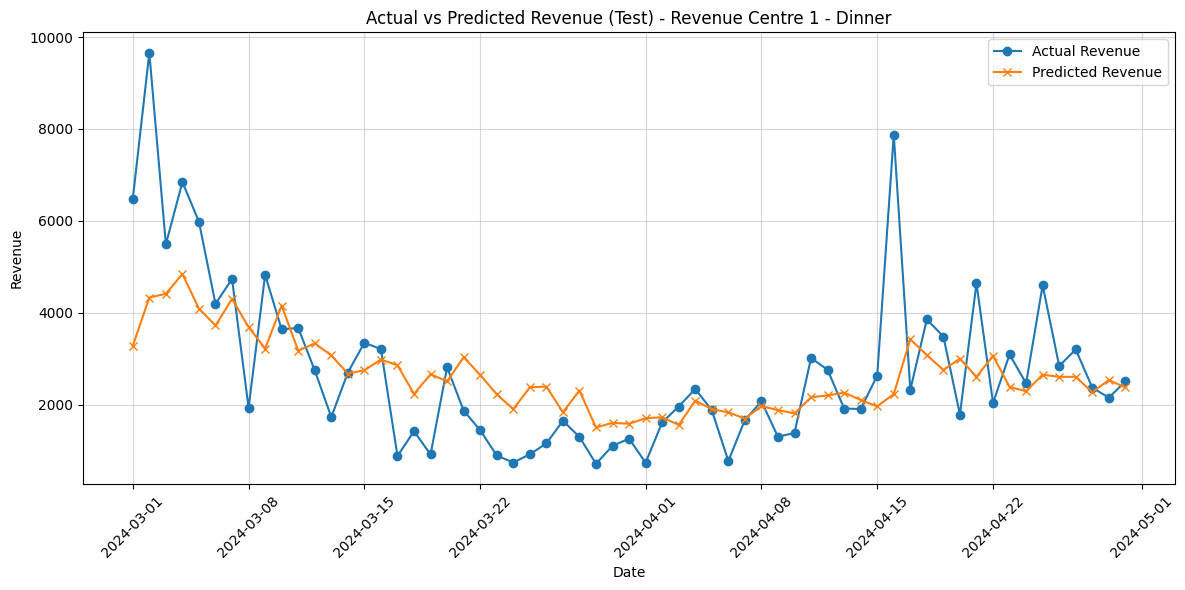

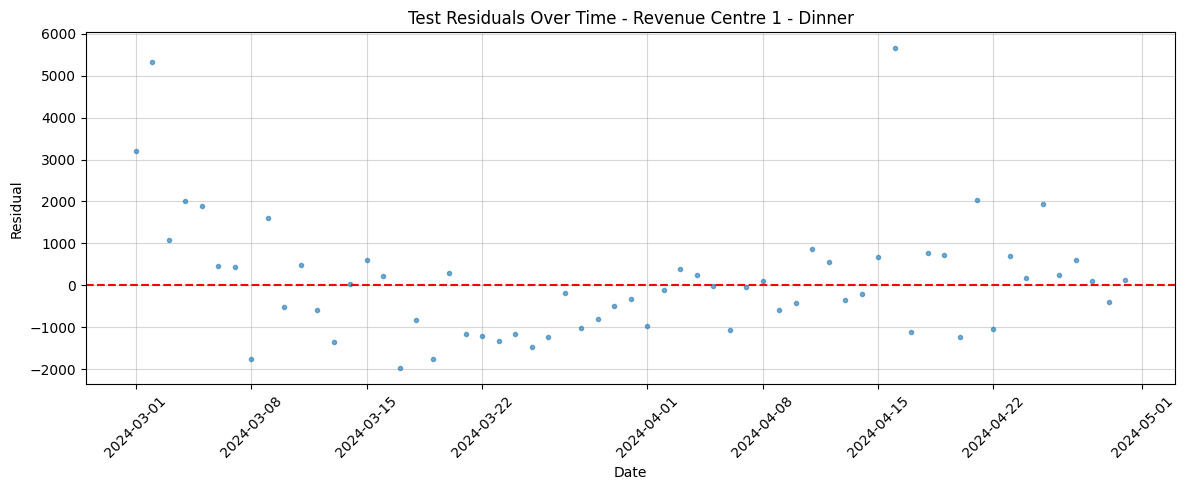

{'Center': 'Revenue Centre 1', 'Meal_Period': 'Dinner', 'Best_LR': 0.001, 'Best_Units': 128, 'Best_Alpha': 10.0, 'CV_RMSE': np.float64(1315.7439), 'CV_W_GRU': 0.3456, 'CV_W_Ridge': 0.6544}
✅ Optimal Params for Revenue Centre 1 - Lunch: LR=0.002, Units=128, Alpha=100.0 | CV RMSE=599.32, Weights(GRU=0.48, Ridge=0.52)
📊 Training Final Model for Revenue Centre 1 - Lunch (LR=0.002, Units=128, Alpha=100.0)


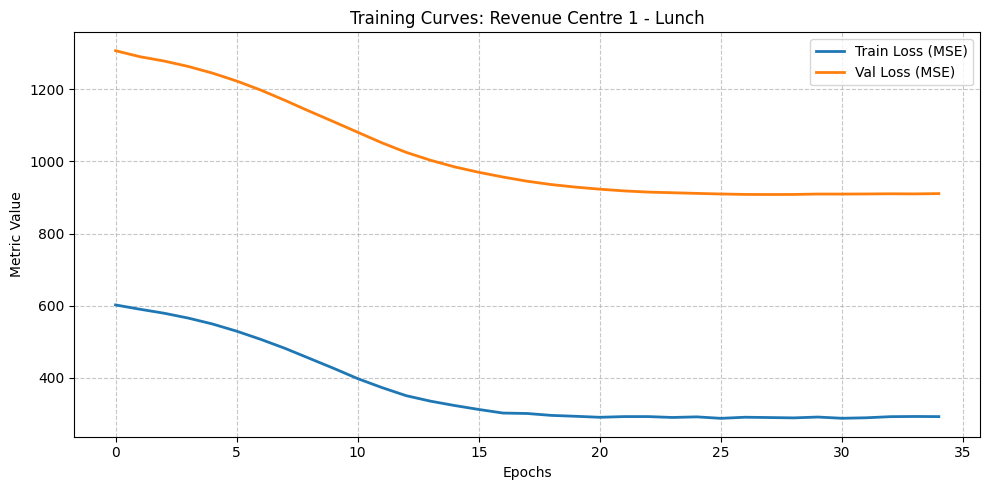

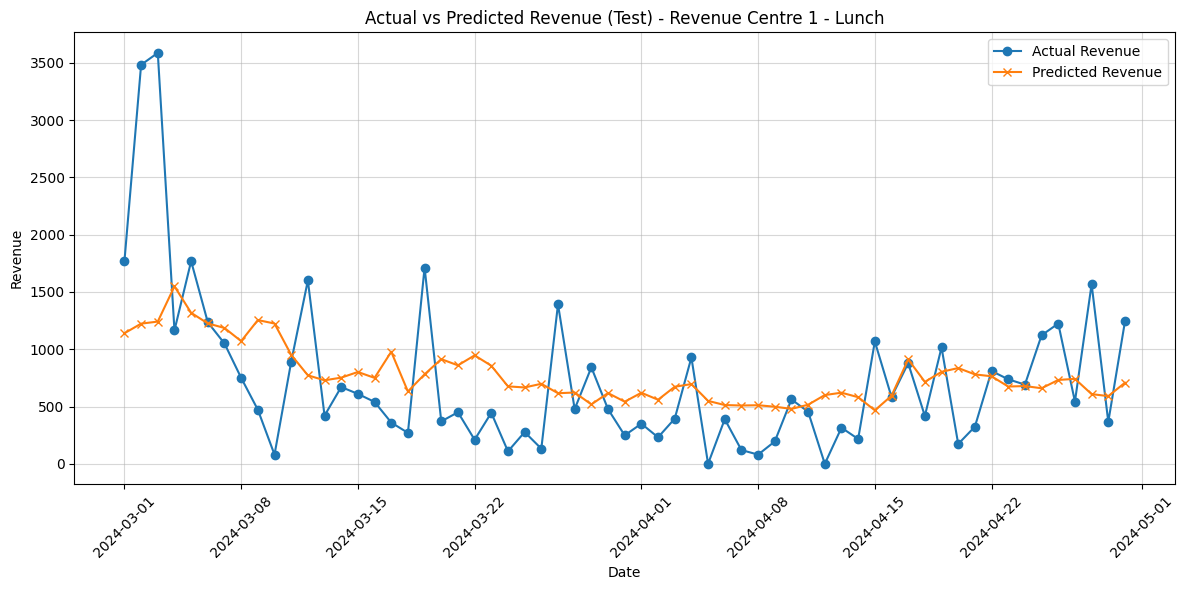

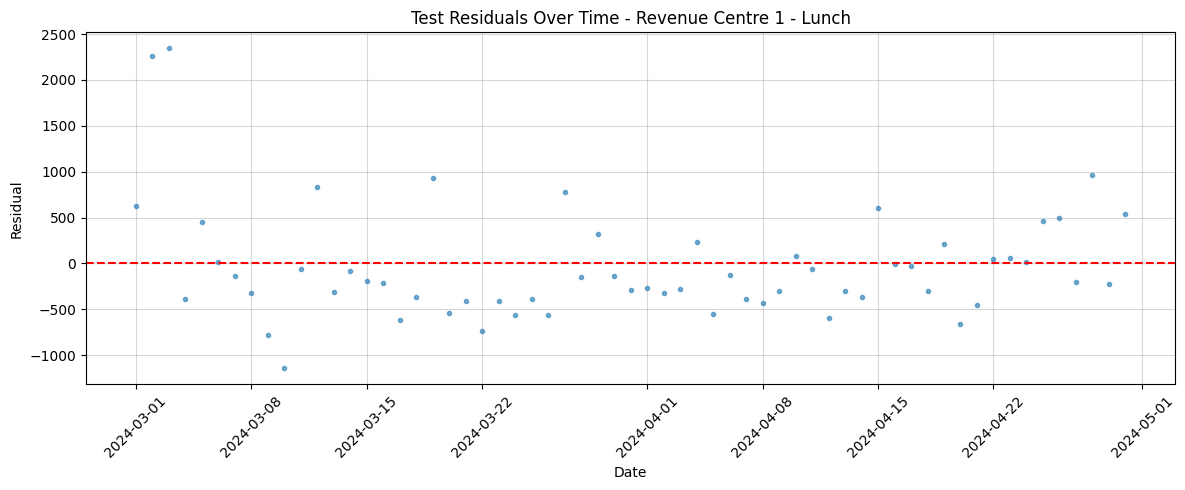

{'Center': 'Revenue Centre 1', 'Meal_Period': 'Lunch', 'Best_LR': 0.002, 'Best_Units': 128, 'Best_Alpha': 100.0, 'CV_RMSE': np.float64(599.3247), 'CV_W_GRU': 0.4801, 'CV_W_Ridge': 0.5199}


In [56]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    """Load one center's sheet from Excel and parse Date column."""
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    # Iterate through centers (adjust range as needed)
    for center_id in range(0, 1):   # change range to loop through more sheets
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            # Run GRU + Ridge training and show plots inline
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")